Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.1840 - val_loss: 0.1069
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0879 - val_loss: 0.0760
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0678 - val_loss: 0.0581
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0649 - val_loss: 0.0602
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0468 - val_loss: 0.0318
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0316 - val_loss: 0.0247
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0246 - val_loss: 0.0192
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0188 - val_loss: 0.0149
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0148 - val_loss: 0.0112
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0112 - val_loss: 0.0090
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
Anomaly threshold: 0.0220413705680161
Number of anomalies detected: 12


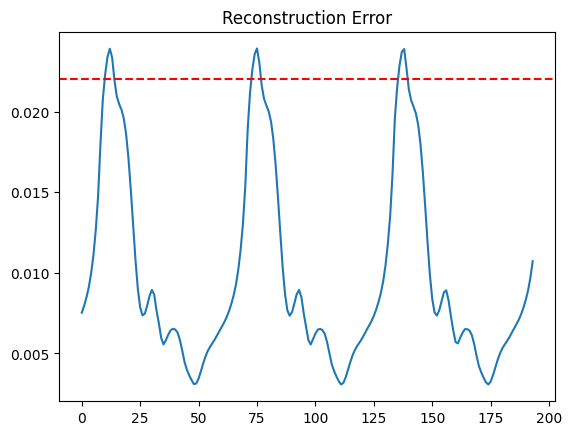

In [1]:
# Import required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generate normal sequential data
np.random.seed(42)
time_steps = 30
features = 1
samples = 1000

data = np.sin(np.linspace(0, 100, samples))
data = data.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, time_steps):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
    return np.array(X)

X = create_sequences(data, time_steps)

# Split dataset
train_size = int(0.8 * len(X))
x_train = X[:train_size]
x_test = X[train_size:]

# Build LSTM Autoencoder model
inputs = Input(shape=(time_steps, features))

encoded = LSTM(64, activation='relu')(inputs)
repeat = RepeatVector(time_steps)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(repeat)
outputs = TimeDistributed(Dense(features))(decoded)

model = Model(inputs, outputs)

# Compile model
model.compile(optimizer='adam', loss='mse')

# Summary
model.summary()

# Train model
history = model.fit(
    x_train, x_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Reconstruction
reconstruction = model.predict(x_test)

# Calculate MSE
mse = np.mean(np.power(x_test - reconstruction, 2), axis=(1, 2))

# Threshold
threshold = np.mean(mse) + 2 * np.std(mse)
print("Anomaly threshold:", threshold)

# Detect anomalies
anomalies = mse > threshold
print("Number of anomalies detected:", np.sum(anomalies))

# Plot reconstruction error
plt.plot(mse)
plt.axhline(threshold, color='r', linestyle='--')
plt.title("Reconstruction Error")
plt.show()